In [2]:
import pandas as pd
from pyvi import ViTokenizer, ViPosTagger
import re
from collections import Counter
import matplotlib.pyplot as plt
from pyvi import ViTokenizer
from underthesea import word_tokenize, pos_tag
import numpy as np
from tqdm import tqdm 
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import os 
import json
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split

c:\Users\NinhDB\tiki-sentiment-analytics\.venv\Lib\site-packages\pyvi\ViTokenizer.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  model = pickle.load(fin)


Load data 

In [3]:
tiki_data = pd.read_csv('./data_scraping/tiki_dataset.csv')
tiki_data.head()

,category,category_name,product_id,product_name,review_id,review,rating,label
0,1883,Nhà Cửa - Đời Sống,277833205,Cốc giữ nhiệt inox 304 Elmich EL8384 dung tích...,20141063,SP đẹp như hình,5,Cực kì hài lòng
1,1883,Nhà Cửa - Đời Sống,277776638,Chảo chống dính Elmich EL5972,20199611,Giao hàng rất nhanh. Đang cần gấp để nấu. Nhưn...,2,Không hài lòng
2,1883,Nhà Cửa - Đời Sống,277776638,Chảo chống dính Elmich EL5972,20197992,"Chảo bị vênh lòng, cao ở giữa, trũng xung quan...",1,Rất không hài lòng
3,1883,Nhà Cửa - Đời Sống,277776638,Chảo chống dính Elmich EL5972,20131003,Hàng dùng tốt,5,Cực kì hài lòng
4,1883,Nhà Cửa - Đời Sống,277740594,Cốc giữ nhiệt inox 304 Elmich 2248380 dung tíc...,20200613,"Bình ok, giá cả hợp lý, màu tím bên ngoài thiê...",5,Cực kì hài lòng


In [4]:
tiki_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84669 entries, 0 to 84668
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   category       84669 non-null  int64 
 1   category_name  84669 non-null  object
 2   product_id     84669 non-null  int64 
 3   product_name   84669 non-null  object
 4   review_id      84669 non-null  int64 
 5   review         84668 non-null  object
 6   rating         84669 non-null  int64 
 7   label          84667 non-null  object
dtypes: int64(4), object(4)
memory usage: 5.2+ MB


Drop missing values

In [5]:
tiki_data.dropna(subset=['review'], inplace=True)
tiki_data.reset_index(drop=True, inplace=True)

In [6]:
tiki_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84668 entries, 0 to 84667
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   category       84668 non-null  int64 
 1   category_name  84668 non-null  object
 2   product_id     84668 non-null  int64 
 3   product_name   84668 non-null  object
 4   review_id      84668 non-null  int64 
 5   review         84668 non-null  object
 6   rating         84668 non-null  int64 
 7   label          84666 non-null  object
dtypes: int64(4), object(4)
memory usage: 5.2+ MB


In [7]:
data = tiki_data[['review', 'rating']]
data

,review,rating
0,SP đẹp như hình,5
1,Giao hàng rất nhanh. Đang cần gấp để nấu. Nhưn...,2
2,"Chảo bị vênh lòng, cao ở giữa, trũng xung quan...",1
3,Hàng dùng tốt,5
4,"Bình ok, giá cả hợp lý, màu tím bên ngoài thiê...",5
...,...,...
84663,Minh nhận gói Maobao khuyến mãi 300g này chung...,5
84664,"Máy giặt của mình đã sử dụng hơn 10 năm rồi, n...",5
84665,"Đã xài rồi, máy giặt ra bẩn quá nhiều luôn, nh...",5
84666,Gia đình mình rất tin dùng sản phẩm Chất Làm S...,5


In [8]:
data.drop_duplicates(inplace=True)
data = data.reset_index()
data.drop(columns=['index'], inplace=True)


C:\Users\NinhDB\AppData\Local\Temp\ipykernel_28772\3360648565.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop_duplicates(inplace=True)


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65744 entries, 0 to 65743
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  65744 non-null  object
 1   rating  65744 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.0+ MB


In [10]:
slang_dict = {
    "k": "không", "ko": "không", "kh": "không", "hok": "không",
    "dc": "được", "đc": "được",
    "sp": "sản phẩm",
    "shop": "cửa hàng",
    "mk": "mình", "mik": "mình",
    "t": "tôi", "toi": "tôi",
    "ok": "tốt", "oki": "tốt", "oke": "tốt",
    "dep": "đẹp", "xau": "xấu",
    "nhanhg": "nhanh",
    "cham": "chậm",
    "tks": "cảm ơn",
    "vs": "với",
    "j": "gì",
    "r": "rồi",
    "nma": "nhưng mà", "nhma": "nhưng mà",
    "tot": "tốt", "khong": "không", "duoc": "được"
}
def normalize_slang(text):
    words = text.split()
    words = [slang_dict.get(word, word) for word in words]
    return " ".join(words)

In [11]:
model_name = "bmd1905/vietnamese-correction-v2"


tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

def predict_correction(text):

    inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt")
    
   
    outputs = model.generate(**inputs, max_length=128)
    
 
    corrected_text = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    return corrected_text[0]

Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

In [12]:
stopwords = [
    "a lô", "ai", "ai đó", "alô", "anh", "ba", "bao giờ", "bao nhiêu", "bây giờ", 
    "bên", "bạn", "bản thân", "bất cứ", "bất kỳ", "bằng", "bởi", "bởi vì", "cho", 
    "cho nên", "cho đến", "chung", "chúng ta", "chúng tôi", "chỉ", "chị", "các", 
    "cách", "cái", "câu hỏi", "còn", "có", "có thể", "cùng", "cũng", "của", "cứ", 
    "do", "do đó", "dù", "dù sao", "dùng", "em", "giờ", "gì", "gần", "gồm", "hay", 
    "hoặc", "hãy", "hơn", "họ", "khi", "khoảng", "khác", "kể", "là", "làm", "lên", 
    "lúc", "lại", "lấy", "mà", "mình", "mọi", "mỗi", "một", "mới", "nay", "ngay", 
    "nghe", "nghĩ", "ngoài", "ngày", "người", "nhau", "nhà", "như", "nhưng", "những", 
    "nào", "này", "nên", "nếu", "nói", "nơi", "nữa", "qua", "ra", "rằng", "rồi", "sau", "so với", "sẽ", "số", "sự", "tại", "theo", "thì", "thế", "thôi", 
    "thường", "thực ra", "tin", "trong", "trên", "trước", "tuy", "tuy nhiên", "từ", 
    "tự", "và", "vài", "vào", "vì", "vì vậy", "với", "vừa", "về", "vậy", "xem", 
    "xin", "yêu cầu", "đang", "đâu", "đây", "đã", "đó", "được", "đến", "đều", 
    "để", "đối với", "ở","shop", "tiki", "hàng", "sản phẩm", "đơn hàng", "đóng gói", "giao hàng",
    "nhé", "nha", "ạ", "ơi", "vâng", "hì", "hi", "chứ", "tiện", "việc", "nhỉ"
]

In [13]:
def remove_stopwords(review): 
    list = review.strip().split()
    words = []
    for word in list:
        if word not in stopwords:
            words.append(word)
    return " ".join(words)

In [14]:
checkpoint_file = "./review_processing_checkpoint.json"

if os.path.exists(checkpoint_file): 
    with open(checkpoint_file, "r", encoding="utf-8") as f: 
        checkpoint = json.load(f)
else: 
    checkpoint = {
        "last_processed_index": 0, 
        "processed_review": []
    }

review_list = data['review']
total_review = len(data['review'])
start_index = checkpoint["last_processed_index"]
print(start_index)
preprocessing_reviews = checkpoint[ "processed_review"]

for i in tqdm(range(start_index, total_review), desc="Preprocessing Review"):
    review = review_list[i]
    review = review.lower()
    review = normalize_slang(review)
    review = predict_correction(review) 
    ''''''
    # remove \n characters in the middle and leading/trailing spaces
    review = review.strip().replace("\n", " ")
    # convert to lower case
    review = re.sub(r"[^\w\sàáảãạâầấẩẫậăằắẳẵặèéẻẽẹêềếểễệìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữựỳýỷỹỵđ]", " ", review)
    # remove special character
    review = re.sub(r"[^\w\s]", " ", review)
    # remove extra spaces
    review = re.sub(r"\s+", " ", review)
    # normalize lengthening
    review = re.sub(r"(.)\1{2,}", r"\1", review)
    review = ViTokenizer.tokenize(review)
    review = remove_stopwords(review) 
    review = review.lower()
    preprocessing_reviews.append(review)
    checkpoint['last_processed_index'] = i+1 
    checkpoint['processed_review'] = preprocessing_reviews 
    with open(checkpoint_file, "w", encoding="utf-8") as f: 
        json.dump(checkpoint, f, ensure_ascii=False, indent=4)

65744


Preprocessing Review: 0it [00:00, ?it/s]


In [15]:
checkpoint_file = r".\review_processing_checkpoint.json"
with open(checkpoint_file, 'r', encoding='utf-8') as f: 
    checkpoint = json.load(f) 
processed_review = checkpoint['processed_review']
processed_review = [review.lower() for review in processed_review]

In [16]:
data['review'] = processed_review
data

,review,rating
0,sản_phẩm đẹp hình,5
1,giao rất nhanh cần gấp nấu mở thất_vọng vô_cùn...,2
2,chảo bị vênh lòng cao giữa trũng xung_quanh rá...,1
3,hàng tốt,5
4,bình_ok giá_cả hợp_lý màu tím thiên màu tím tr...,5
...,...,...
65739,minh nhận gói maobao khuyến_mãi 300g bột_giặt ...,5
65740,máy_giặt sử_dụng 10 năm nhiều giặt đồ cảm_giác...,5
65741,xài máy_giặt bẩn quá nhiều luôn nhìn thấy sợ k...,5
65742,gia_đình rất tin_dùng sản_phẩm_chất sạch lồng ...,5


In [17]:
data.duplicated().any()

np.True_

In [18]:
data.drop_duplicates(inplace=True)

In [19]:
data = data[data['review']!=""]
mapping = {
    1:0, 
    2:0, 
    3:1, 
    4:2, 
    5:2
}
data['target'] = data['rating'].map(mapping)
data = data[['review', 'target']] 


C:\Users\NinhDB\AppData\Local\Temp\ipykernel_28772\3110148168.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['target'] = data['rating'].map(mapping)


In [20]:
data_file = './data/data.csv'
data.to_csv(data_file, index=False, encoding="utf-8-sig")

Local

In [21]:
data_file = "./data/data.csv"
tiki_data = pd.read_csv(data_file)

In [22]:
tiki_data['target'].value_counts().to_frame()

,count
target,
2,49607
0,7160
1,3828


C:\Users\NinhDB\AppData\Local\Temp\ipykernel_28772\3326679393.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=tiki_data, x=tiki_data['target'],palette='Set2')


<Axes: xlabel='target', ylabel='count'>

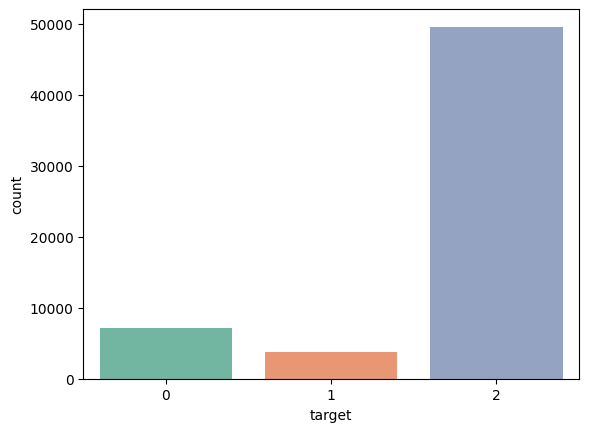

In [23]:
sns.countplot(data=tiki_data, x=tiki_data['target'],palette='Set2')

In [24]:
all_words = []
for review in tiki_data['review']:
    words = review.strip().split()
    for word in words: all_words.append(word)
word_counts = Counter(all_words)

In [26]:
word_counts_df = pd.DataFrame(word_counts.items(), columns=['word', 'frequency'])
word_counts_df = word_counts_df.sort_values(by='frequency', ascending=False)

In [27]:
def wordcloud(target):  
    text = " ".join(tiki_data[tiki_data['target'] == target]['review'])

    wordcloud = WordCloud (
        width=800,
        height=600,
        background_color="white",
        font_path="arial.ttf"
    ).generate(text)

    plt.figure(figsize=(12,6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    if target == 2: 
        plt.title("Positive Wordcloud")
    elif target == 1: 
        plt.title("Neutral WordsCloud") 
    else: 
        plt.title("Negative WordsCloud")
    plt.show()

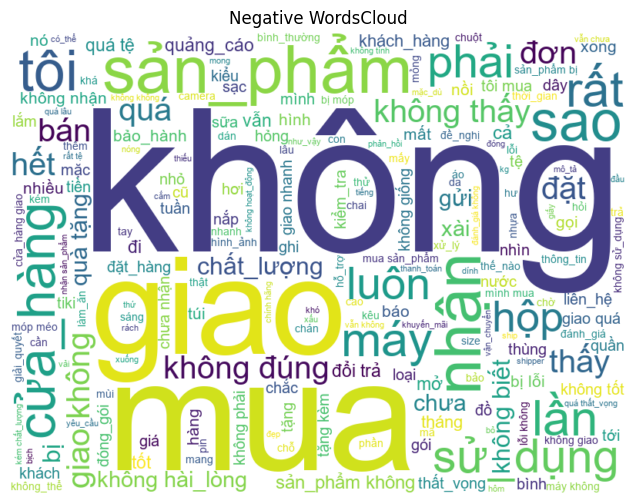

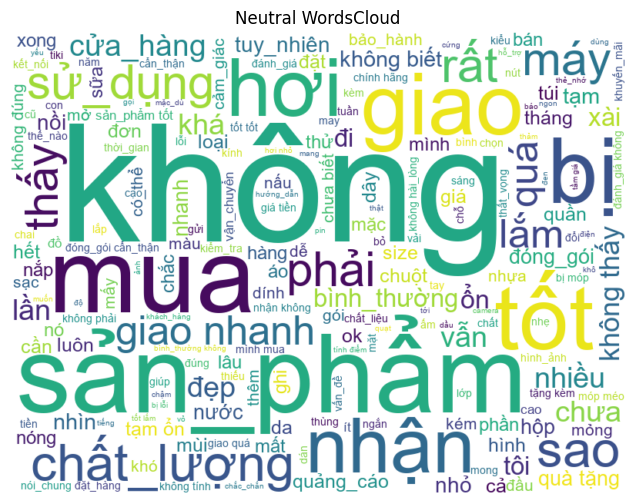

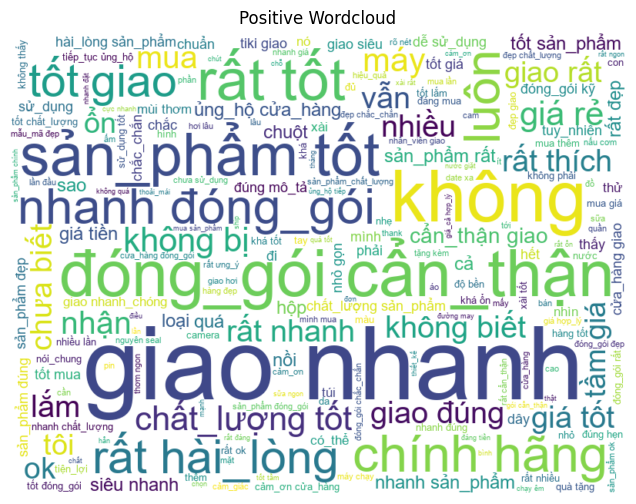

In [28]:
for target in range(0, 3): 
    wordcloud(target)

In [29]:
train_set, test_set = train_test_split(
    tiki_data, 
    test_size=0.2, 
    random_state=42, 
    stratify=tiki_data['target'] 
)

C:\Users\NinhDB\AppData\Local\Temp\ipykernel_28772\835859572.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_set, x=train_set['target'],palette='Set2')


<Axes: xlabel='target', ylabel='count'>

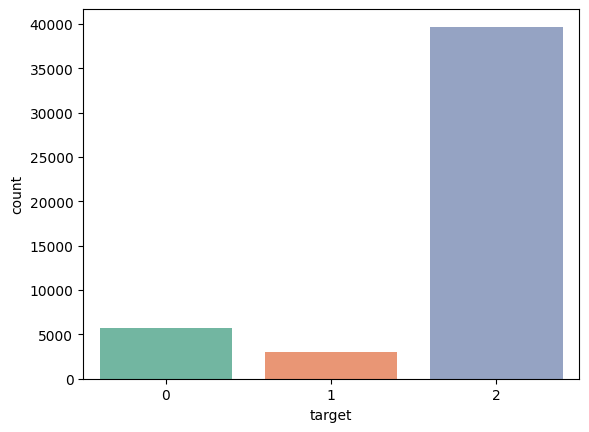

In [30]:
sns.countplot(data=train_set, x=train_set['target'],palette='Set2')

C:\Users\NinhDB\AppData\Local\Temp\ipykernel_28772\3194326540.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=test_set, x=test_set['target'],palette='Set2')


<Axes: xlabel='target', ylabel='count'>

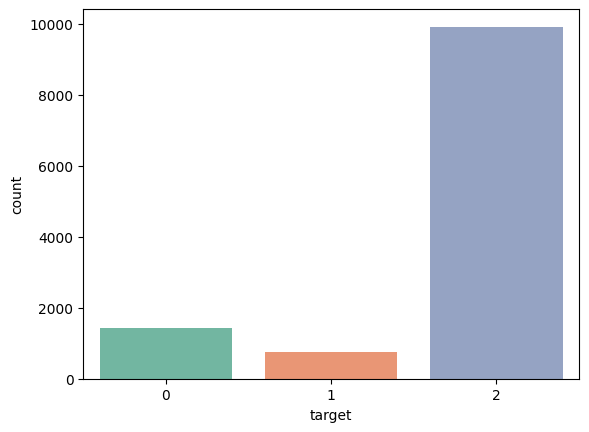

In [31]:
sns.countplot(data=test_set, x=test_set['target'],palette='Set2')

In [32]:
train_path = "./data/train.csv" 
test_path = "./data/test.csv" 
train_set.to_csv(train_path, index=False, encoding="utf-8-sig") 
test_set.to_csv(test_path, index=False, encoding="utf-8-sig") 